# 06 -- RFM 用户分层与运营策略

---

## 业务背景

前面我们分析了销售、用户、商品、漏斗，现在要回答一个最核心的运营问题：

**"给哪些用户发优惠券？给哪些用户推新品？哪些用户快流失了需要挽回？"**

RFM 模型是回答这些问题的经典框架：

- **R (Recency)**：最近一次购买距今多少天？—— 越近越好
- **F (Frequency)**：买了多少次？—— 越多越好
- **M (Monetary)**：一共花了多少钱？—— 越高越好

每个用户拿到 R、F、M 三个分数（1-5），然后按分数组合划分到 11 个客群中。每个客群有不同的运营策略。

**这是整个项目中最受面试官欢迎的分析模块。**

## 1. 环境与数据

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "WenQuanYi Micro Hei", "sans-serif"]
plt.rcParams["axes.unicode_minus"] = False

txn = pd.read_parquet('../output/transactions_wide.parquet')
customers = pd.read_parquet('../output/customers_clean.parquet')

completed = txn[txn['status'] == 'completed'].copy()

# 定义"现在"为数据中最后一天 + 1
NOW = completed['transaction_date'].max() + pd.Timedelta(days=1)
print(f"参考日期 (NOW): {NOW.date()}")

C:\Users\Acer\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


参考日期 (NOW): 2024-12-31


## 2. 计算 RFM 值

以每个 customer_id 为单位，计算 R、F、M。

In [2]:
# 计算 RFM
rfm = completed.groupby('customer_id').agg(
    recency=('transaction_date', lambda x: (NOW - x.max()).days),  # R: 距最后购买天数
    frequency=('transaction_id', 'nunique'),  # F: 购买次数
    monetary=('total_amount', 'sum')  # M: 总消费金额
).reset_index()

# 合并用户画像信息
rfm = rfm.merge(customers[['customer_id', 'segment', 'country', 'is_churned']],
                on='customer_id', how='left')

print(f"RFM 表: {len(rfm):,} 用户")
print(f"\n=== R 分布 ===")
print(rfm['recency'].describe())
print(f"\n=== F 分布 ===")
print(rfm['frequency'].describe())
print(f"\n=== M 分布 ===")
print(rfm['monetary'].describe())

RFM 表: 9,730 用户

=== R 分布 ===
count    9730.000000
mean      130.997122
std       139.848001
min         1.000000
25%        33.000000
50%        82.000000
75%       177.000000
max       730.000000
Name: recency, dtype: float64

=== F 分布 ===
count    9730.000000
mean        7.060637
std         4.683993
min         1.000000
25%         4.000000
50%         6.000000
75%        10.000000
max        30.000000
Name: frequency, dtype: float64

=== M 分布 ===
count    9730.000000
mean      559.429398
std       511.404010
min         2.680000
25%       199.997500
50%       421.850000
75%       761.212500
max      7346.460000
Name: monetary, dtype: float64


## 3. RFM 三维分布可视化

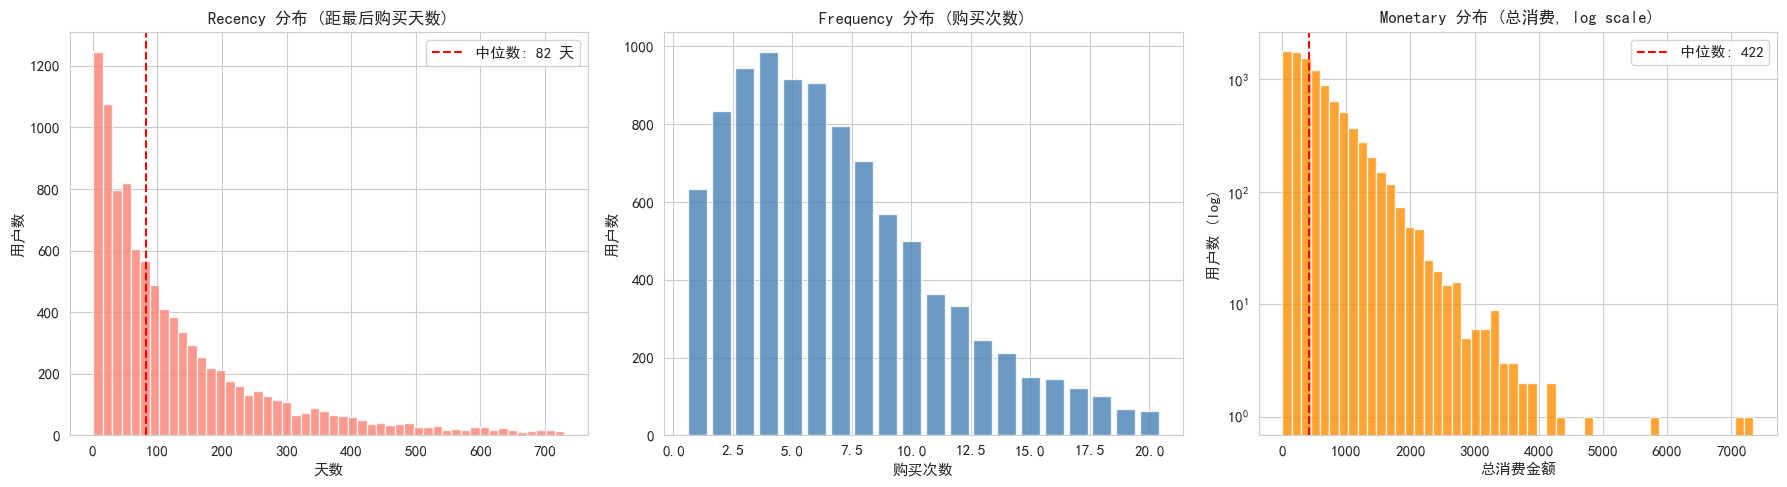

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# R 分布
axes[0].hist(rfm['recency'], bins=50, color='salmon', alpha=0.8, edgecolor='white')
axes[0].axvline(x=rfm['recency'].median(), color='red', linestyle='--',
                label=f"中位数: {rfm['recency'].median():.0f} 天")
axes[0].set_title('Recency 分布 (距最后购买天数)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('天数')
axes[0].set_ylabel('用户数')
axes[0].legend()

# F 分布
freq_dist = rfm['frequency'].value_counts().sort_index()
freq_plot = freq_dist[freq_dist.index <= 20]
axes[1].bar(freq_plot.index, freq_plot.values, color='steelblue', alpha=0.8)
axes[1].set_title('Frequency 分布 (购买次数)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('购买次数')
axes[1].set_ylabel('用户数')

# M 分布（log scale）
axes[2].hist(rfm['monetary'], bins=50, color='darkorange', alpha=0.8, edgecolor='white', log=True)
axes[2].axvline(x=rfm['monetary'].median(), color='red', linestyle='--',
                label=f"中位数: {rfm['monetary'].median():.0f}")
axes[2].set_title('Monetary 分布 (总消费, log scale)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('总消费金额')
axes[2].set_ylabel('用户数 (log)')
axes[2].legend()

plt.tight_layout()
plt.show()

**业务观察：**
- R 分布是"越近越好"，理想情况是左偏（大部分用户最近买过）
- F 分布高度右偏是正常的——绝大多数人只买 1-2 次
- M 分布也是右偏，印证了此前 LTV 分析的结论


## 4. RFM 评分（1-5 分制）

用五分位数将每个指标分成 5 档：
- **R 分：** 最近购买 → 5 分（天数少），很久没买 → 1 分（天数多）
- **F 分：** 购买次数多 → 5 分，少 → 1 分
- **M 分：** 消费金额高 → 5 分，低 → 1 分

In [4]:
# R 评分：天数越少分越高（反向打分）
rfm['R_score'] = pd.qcut(rfm['recency'], q=5, labels=[5, 4, 3, 2, 1]).astype(int)

# F 评分：次数越多分越高
try:
    rfm['F_score'] = pd.qcut(rfm['frequency'], q=5, labels=[1, 2, 3, 4, 5], duplicates='drop').astype(int)
except ValueError:
    # 如果频次重复值太多，手动处理
    rfm['F_score'] = pd.cut(rfm['frequency'], bins=5, labels=[1, 2, 3, 4, 5]).astype(int)

# M 评分：金额越多分越高
try:
    rfm['M_score'] = pd.qcut(rfm['monetary'], q=5, labels=[1, 2, 3, 4, 5], duplicates='drop').astype(int)
except ValueError:
    rfm['M_score'] = pd.cut(rfm['monetary'], bins=5, labels=[1, 2, 3, 4, 5]).astype(int)

# RFM 综合分
rfm['RFM_score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

print("=== RFM 评分分布 ===")
for col in ['R_score', 'F_score', 'M_score']:
    print(f"\n{col}:")
    print(rfm[col].value_counts().sort_index())

print(f"\nRFM 综合分分布:")
print(rfm['RFM_score'].describe())

=== RFM 评分分布 ===

R_score:
R_score
1    1942
2    1926
3    1927
4    1953
5    1982
Name: count, dtype: int64

F_score:
F_score
1    2412
2    1903
3    1700
4    1775
5    1940
Name: count, dtype: int64

M_score:
M_score
1    1946
2    1946
3    1946
4    1946
5    1946
Name: count, dtype: int64

RFM 综合分分布:
count    9730.000000
mean        8.900822
std         3.626505
min         3.000000
25%         6.000000
50%         9.000000
75%        12.000000
max        15.000000
Name: RFM_score, dtype: float64


## 5. 用户分群

基于 R、F、M 分数组合，将用户划分到 11 个运营客群。这是 RFM 模型最关键的一步。

In [5]:
def segment_rfm(row):
    """根据 R/F/M 分数划分客群"""
    r, f, m = row['R_score'], row['F_score'], row['M_score']
    avg = (r + f + m) / 3

    # 核心客群
    if r >= 4 and f >= 4 and m >= 4:
        return '冠军用户'
    if r >= 4 and f >= 3 and m >= 3:
        return '忠诚用户'
    if r >= 4 and f <= 2 and m >= 4:
        return '高消费新客'
    if r >= 4 and f <= 2 and m <= 3:
        return '新客户'

    # 潜力客群
    if r >= 3 and f >= 3 and m >= 3:
        return '潜力用户'
    if r <= 2 and f >= 4 and m >= 4:
        return '需挽回高价值'
    if r <= 2 and f >= 3 and m >= 3:
        return '有流失风险'

    # 沉睡/流失客群
    if r <= 2 and f >= 2 and m >= 2:
        return '即将流失'
    if r <= 2 and f <= 1 and m >= 3:
        return '一次性大客户'
    if r <= 2 and f <= 1 and m <= 2:
        return '已流失'

    return '一般用户'

rfm['segment_rfm'] = rfm.apply(segment_rfm, axis=1)

# 客群统计
segment_stats = rfm.groupby('segment_rfm').agg(
    用户数=('customer_id', 'nunique'),
    占比=('customer_id', lambda x: len(x) / len(rfm) * 100),
    平均R天数=('recency', 'mean'),
    平均购买次数=('frequency', 'mean'),
    平均消费额=('monetary', 'mean'),
    总消费额=('monetary', 'sum'),
    流失率=('is_churned', 'mean')
).sort_values('用户数', ascending=False)

segment_stats['GMV占比'] = segment_stats['总消费额'] / rfm['monetary'].sum() * 100

print("=== 客群画像 ===")
print(segment_stats.round(1).to_string())

=== 客群画像 ===
              用户数    占比  平均R天数  平均购买次数   平均消费额       总消费额  流失率  GMV占比
segment_rfm                                                          
冠军用户         1849  19.0   25.4    13.2  1142.6  2112732.4  0.1   38.8
已流失          1544  15.9  335.9     1.9   107.0   165227.2  0.3    3.0
一般用户         1312  13.5   93.9     4.8   234.7   307870.5  0.2    5.7
潜力用户         1066  11.0   83.2    10.2   812.0   865573.1  0.1   15.9
即将流失          945   9.7  217.0     5.0   370.7   350311.5  0.2    6.4
忠诚用户          837   8.6   28.0     7.8   560.9   469432.0  0.2    8.6
新客户           825   8.5   29.5     3.7   236.2   194884.4  0.2    3.6
有流失风险         577   5.9  187.5     7.2   558.2   322104.5  0.1    5.9
需挽回高价值        422   4.3  164.0    10.7   976.9   412255.9  0.1    7.6
一次性大客户        199   2.0  313.3     2.5   570.3   113493.6  0.2    2.1
高消费新客         154   1.6   30.1     4.2   840.0   129362.9  0.2    2.4


## 6. 客群可视化

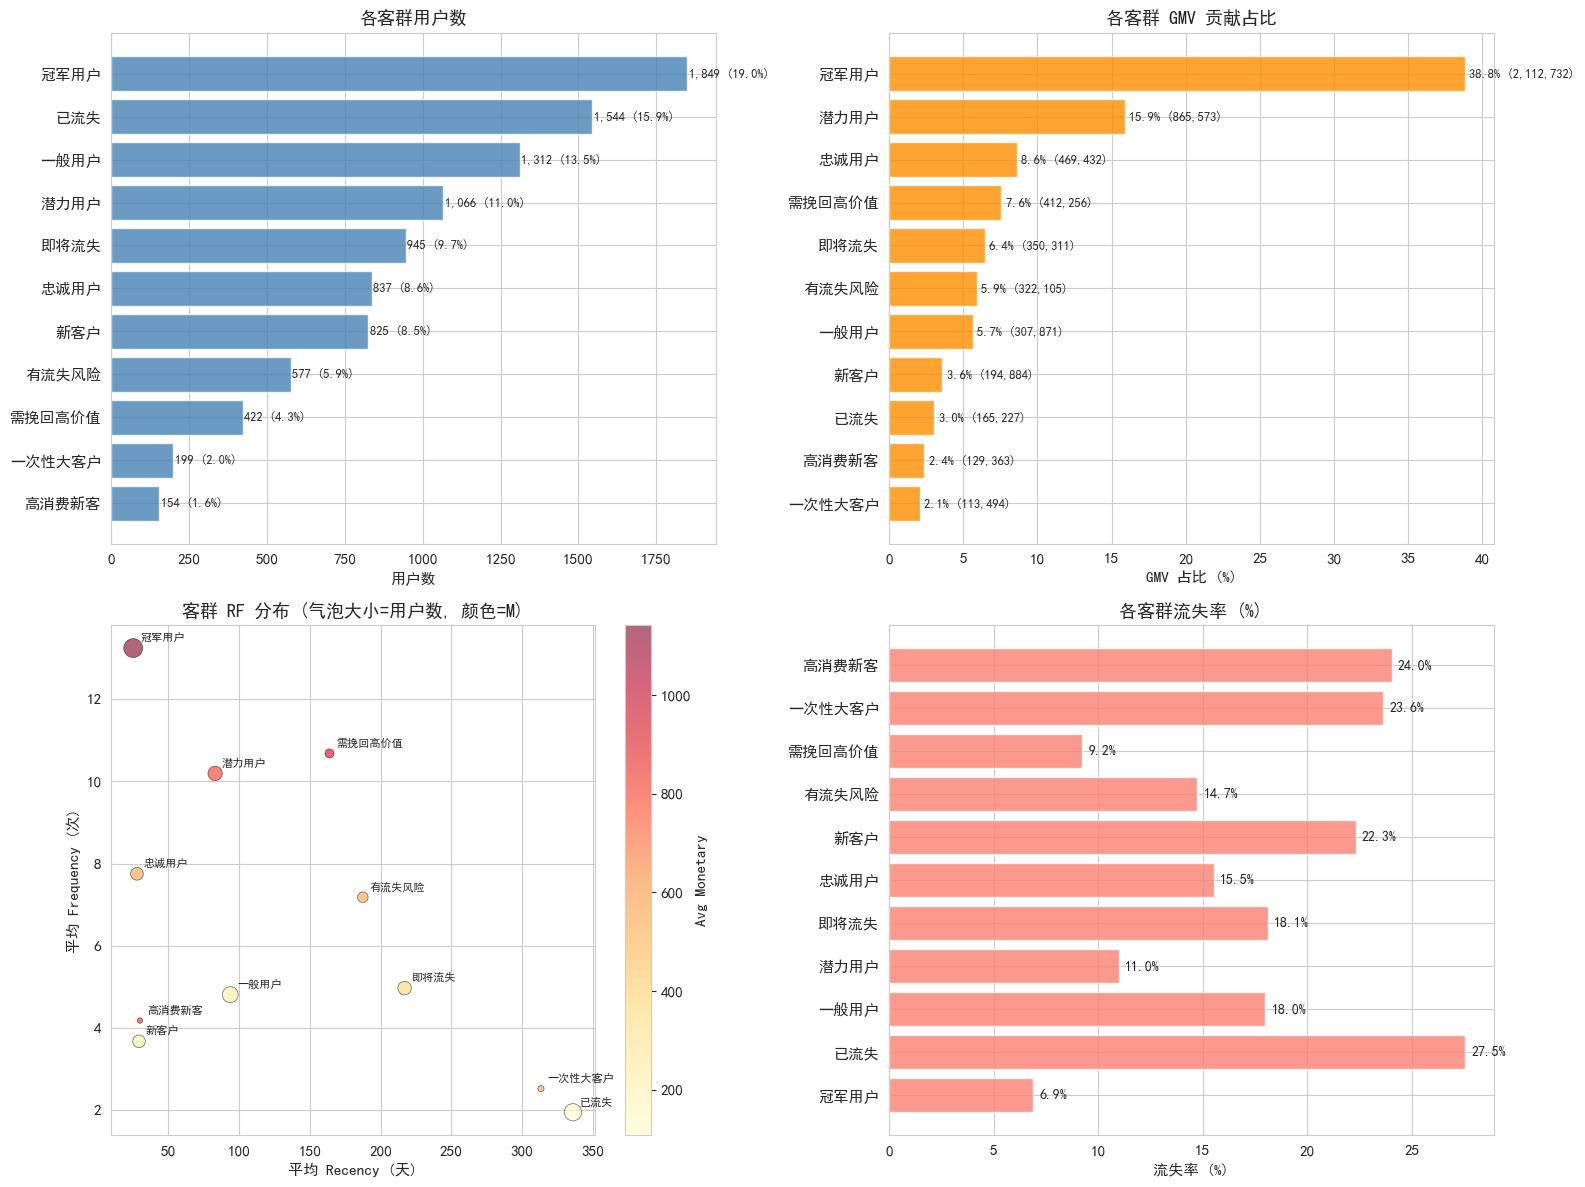

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 客群人数分布（横向柱状图）
seg_count = segment_stats.sort_values('用户数')
axes[0, 0].barh(seg_count.index, seg_count['用户数'], color='steelblue', alpha=0.8)
axes[0, 0].set_title('各客群用户数', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('用户数')
for i, (cnt, pct) in enumerate(zip(seg_count['用户数'], seg_count['占比'])):
    axes[0, 0].text(cnt + 5, i, f'{cnt:,} ({pct:.1f}%)', va='center', fontsize=9)

# 客群 GMV 贡献
seg_gmv = segment_stats.sort_values('GMV占比')
axes[0, 1].barh(seg_gmv.index, seg_gmv['GMV占比'], color='darkorange', alpha=0.8)
axes[0, 1].set_title('各客群 GMV 贡献占比', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('GMV 占比 (%)')
for i, (pct, total) in enumerate(zip(seg_gmv['GMV占比'], seg_gmv['总消费额'])):
    axes[0, 1].text(pct + 0.3, i, f'{pct:.1f}% ({total:,.0f})', va='center', fontsize=9)

# 客群 R × F 散点图
seg_avg = segment_stats.copy()
scatter = axes[1, 0].scatter(
    seg_avg['平均R天数'], seg_avg['平均购买次数'],
    s=seg_avg['用户数'] / 10, alpha=0.6,
    c=seg_avg['平均消费额'], cmap='YlOrRd',
    edgecolors='black', linewidth=0.5
)
axes[1, 0].set_xlabel('平均 Recency (天)')
axes[1, 0].set_ylabel('平均 Frequency (次)')
axes[1, 0].set_title('客群 RF 分布 (气泡大小=用户数, 颜色=M)', fontsize=13, fontweight='bold')
for name, row in seg_avg.iterrows():
    axes[1, 0].annotate(name, (row['平均R天数'], row['平均购买次数']),
                        textcoords="offset points", xytext=(5, 5), fontsize=8)
plt.colorbar(scatter, ax=axes[1, 0], label='Avg Monetary')

# 客群流失率
axes[1, 1].barh(seg_avg.index, seg_avg['流失率'] * 100, color='salmon', alpha=0.8)
axes[1, 1].set_title('各客群流失率 (%)', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('流失率 (%)')
for i, v in enumerate(seg_avg['流失率'] * 100):
    axes[1, 1].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()

## 7. 各客群运营策略

这是 RFM 分析的价值落地点——不是只打分，而是告诉运营每个客群该做什么。

In [7]:
# 为每类客群制定运营策略
strategies = {
    '冠军用户': {
        '策略': 'VIP 专属服务 + 新品优先体验',
        '触达频率': '每月 1-2 次',
        '优惠力度': '专属折扣（非公开）',
        '核心动作': '邀请写评测、参与用户访谈、推荐有礼',
        'KPI': '维持 R < 30 天，年消费增长 20%'
    },
    '忠诚用户': {
        '策略': '会员体系绑定 + 周期性复购提醒',
        '触达频率': '每 2 周 1 次',
        '优惠力度': '会员折扣 + 满减券',
        '核心动作': '提升 F 分数，从 Loyal 升级为 Champion',
        'KPI': 'F 增长 50%，升级到冠军用户'
    },
    '高消费新客': {
        '策略': '首单后 7 天关怀 + 搭配推荐',
        '触达频率': '首月 3 次',
        '优惠力度': '第二单 9 折券',
        '核心动作': '根据首单品类推荐关联商品，促成复购',
        'KPI': '30 天内产生第二单，F 从 1 升到 2'
    },
    '新客户': {
        '策略': '引导完成首次购买后的 APP 下载 + 注册会员',
        '触达频率': '首月 2 次',
        '优惠力度': '新人专享券',
        '核心动作': '推送 APP 下载福利、完善用户画像',
        'KPI': 'APP 安装率，首单后留存率'
    },
    '潜力用户': {
        '策略': '周期性优惠 + 新品推荐',
        '触达频率': '每月 2 次',
        '优惠力度': '阶梯优惠（买越多省越多）',
        '核心动作': '提升消费频次和客单价，向忠诚用户转化',
        'KPI': 'M 增长 30%，F 增长 1'
    },
    '需挽回高价值': {
        '策略': '大力度召回券 + 专属客服触达',
        '触达频率': '每周 1 次 × 3 周',
        '优惠力度': '满减券（面额较大）',
        '核心动作': 'Push + 短信 + 邮件 3 通道召回，强调"我们想你了"',
        'KPI': '30 天内召回率 > 15%'
    },
    '有流失风险': {
        '策略': '预测性挽回 + 权益提醒',
        '触达频率': '每 10 天 1 次',
        '优惠力度': '定向优惠券',
        '核心动作': '提醒会员权益即将到期、积分即将过期',
        'KPI': 'R 分数回升至 3+'
    },
    '即将流失': {
        '策略': '最后机会：大折扣 + 限时优惠',
        '触达频率': '紧急频次（不骚扰即可）',
        '优惠力度': '大额券（如满 100-30）',
        '核心动作': '限时折扣 + 库存紧张提醒，制造紧迫感',
        'KPI': '召回率 > 10%'
    },
    '一次性大客户': {
        '策略': '分析首单品类 → 精准推荐关联品类',
        '触达频率': '每月 1 次',
        '优惠力度': '小幅度优惠',
        '核心动作': '基于首单品类的关联推荐，降低复购门槛',
        'KPI': '产生第二单'
    },
    '已流失': {
        '策略': '低成本批量触达（如果 ROI 为正则尝试挽回）',
        '触达频率': '每季度 1 次',
        '优惠力度': '大额召回券',
        '核心动作': 'EDM 批量推送 + 品牌故事/新品吸引',
        'KPI': '召回 ROI > 1 则继续，否则放弃'
    },
    '一般用户': {
        '策略': '常规运营，不做重点投入',
        '触达频率': '每月 1 次',
        '优惠力度': '平台通用券',
        '核心动作': '放在常规 EDM 列表中，不单独做策略',
        'KPI': '不恶化即可'
    }
}

strategy_df = pd.DataFrame.from_dict(strategies, orient='index')
strategy_df.index.name = '客群'

# 合并统计数据
full_segment = segment_stats.join(strategy_df)
print("=== 完整客群运营策略 ===")
for seg in full_segment.index:
    row = full_segment.loc[seg]
    print(f"\n{'='*60}")
    print(f"【{seg}】  用户数: {row['用户数']:,}  ({row['占比']:.1f}%)  |  GMV 占比: {row['GMV占比']:.1f}%")
    print(f"  平均 R: {row['平均R天数']:.0f} 天 | 平均 F: {row['平均购买次数']:.1f} 次 | 平均 M: {row['平均消费额']:.0f}")
    print(f"  流失率: {row['流失率']:.1%}")
    print(f"  策略: {row['策略']}")
    print(f"  触达: {row['触达频率']} | 优惠: {row['优惠力度']}")
    print(f"  核心动作: {row['核心动作']}")
    print(f"  KPI: {row['KPI']}")

=== 完整客群运营策略 ===

【冠军用户】  用户数: 1,849  (19.0%)  |  GMV 占比: 38.8%
  平均 R: 25 天 | 平均 F: 13.2 次 | 平均 M: 1143
  流失率: 6.9%
  策略: VIP 专属服务 + 新品优先体验
  触达: 每月 1-2 次 | 优惠: 专属折扣（非公开）
  核心动作: 邀请写评测、参与用户访谈、推荐有礼
  KPI: 维持 R < 30 天，年消费增长 20%

【已流失】  用户数: 1,544  (15.9%)  |  GMV 占比: 3.0%
  平均 R: 336 天 | 平均 F: 1.9 次 | 平均 M: 107
  流失率: 27.5%
  策略: 低成本批量触达（如果 ROI 为正则尝试挽回）
  触达: 每季度 1 次 | 优惠: 大额召回券
  核心动作: EDM 批量推送 + 品牌故事/新品吸引
  KPI: 召回 ROI > 1 则继续，否则放弃

【一般用户】  用户数: 1,312  (13.5%)  |  GMV 占比: 5.7%
  平均 R: 94 天 | 平均 F: 4.8 次 | 平均 M: 235
  流失率: 18.0%
  策略: 常规运营，不做重点投入
  触达: 每月 1 次 | 优惠: 平台通用券
  核心动作: 放在常规 EDM 列表中，不单独做策略
  KPI: 不恶化即可

【潜力用户】  用户数: 1,066  (11.0%)  |  GMV 占比: 15.9%
  平均 R: 83 天 | 平均 F: 10.2 次 | 平均 M: 812
  流失率: 11.0%
  策略: 周期性优惠 + 新品推荐
  触达: 每月 2 次 | 优惠: 阶梯优惠（买越多省越多）
  核心动作: 提升消费频次和客单价，向忠诚用户转化
  KPI: M 增长 30%，F 增长 1

【即将流失】  用户数: 945  (9.7%)  |  GMV 占比: 6.4%
  平均 R: 217 天 | 平均 F: 5.0 次 | 平均 M: 371
  流失率: 18.1%
  策略: 最后机会：大折扣 + 限时优惠
  触达: 紧急频次（不骚扰即可） | 优惠: 大额券（如满 100-30）
  核心动作: 限时折扣 + 库存紧张提醒，制

## 8. 客群价值优先级矩阵

综合用户数和单用户价值，绘制运营优先级热力图。

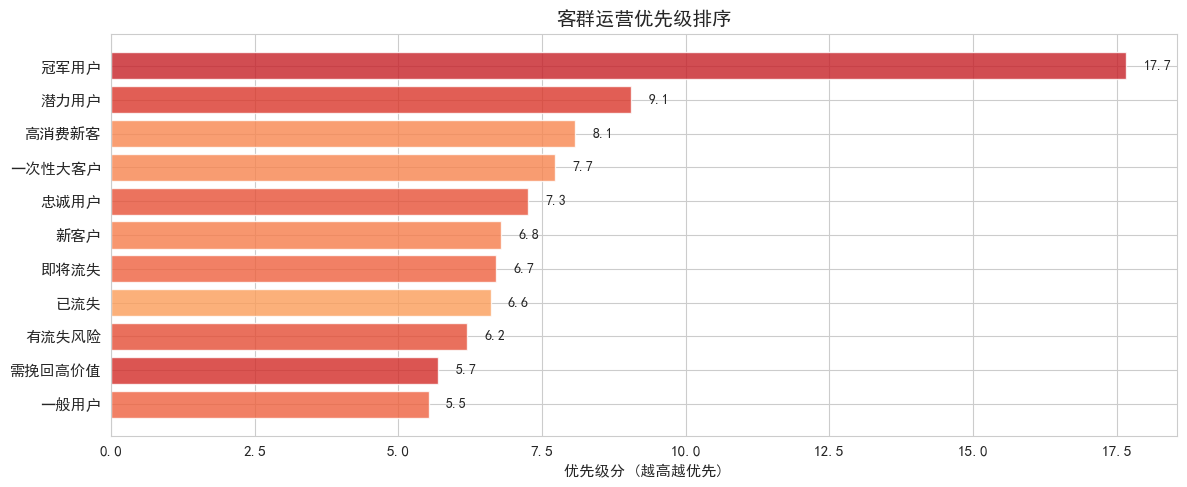

In [8]:
# 构建优先级矩阵
priority = pd.DataFrame({
    '客群': segment_stats.index,
    '用户数占比': segment_stats['占比'],
    '人均GMV': segment_stats['平均消费额'],
    'GMV占比': segment_stats['GMV占比'],
    '流失风险': segment_stats['流失率']
})
priority['优先级分'] = (
    priority['GMV占比'] * 0.5 +
    priority['流失风险'] * 100 * 0.3 -
    priority['用户数占比'] * 0.2
)
priority = priority.sort_values('优先级分', ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
colors = plt.cm.RdYlGn(priority['流失风险'].values)
ax.barh(priority['客群'], priority['优先级分'], color=colors, alpha=0.8)
ax.set_title('客群运营优先级排序', fontsize=14, fontweight='bold')
ax.set_xlabel('优先级分 (越高越优先)')
ax.invert_yaxis()

for i, (score, seg) in enumerate(zip(priority['优先级分'], priority['客群'])):
    ax.text(score + 0.3, i, f'{score:.1f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

**运营资源分配建议：**
- 优先级 Top 3 的客群投入 60% 的运营资源（人力+预算）
- 高价值 + 高流失风险 = 最高优先级（不救就没了）
- 高价值 + 低流失风险 = 维持型运营
- 低价值 + 高流失风险 = 低成本批量挽回
- 低价值 + 低流失风险 = 不主动投入


---

## 9.小结

| 客群 | 占用户数 | 占 GMV | 核心策略 |
|------|---------|--------|---------|
| 冠军用户 | 见统计 | 见统计 | VIP 维护，保持活跃度 |
| 忠诚用户 | 见统计 | 见统计 | 提升为冠军，增加复购 |
| 需挽回高价值 | 见统计 | 见统计 | 强烈召回，3 通道触达 |
| 已流失 | 见统计 | 见统计 | 低成本批量，ROI 决定去留 |

**RFM 模型的精髓：** 不在于算得分，而在于**为每个得分组合设计可执行的运营动作**。一个好的 RFM 分析，交给运营团队就能直接落地。
